In [2]:
import numpy as np

import src.bext.aext as aext
from src.bext.aext import _A_single_n_turn_coil, curlA, compute_A_polywell, POLYWELL_COILS
from src.bext.aext import _n_turn_Aphi_vec_linear_dropoff_current, _n_turn_Aphi_vec_exponential_dropoff_current

import matplotlib.pyplot as plt

from openpmd_viewer import OpenPMDTimeSeries

# Grab the data to take r1/r2 from

In [3]:
series_f = OpenPMDTimeSeries('diags/')

In [4]:
it = series_f.iterations[0]
jx, info = series_f.get_field(field='j', coord='x', slice_across='y', iteration=it)
jy, _ = series_f.get_field(field='j', coord='y', slice_across='y', iteration=it)
jz, _ = series_f.get_field(field='j', coord='z', slice_across='y', iteration=it)

jex, _ = series_f.get_field(field='j_displacement', coord='x', slice_across='y', iteration=it)
jey, _ = series_f.get_field(field='j_displacement', coord='y', slice_across='y', iteration=it)
jez, _ = series_f.get_field(field='j_displacement', coord='z', slice_across='y', iteration=it)

jt_x = jx + jex
jt_y = jy + jey
jt_z = jz + jez

max_z = np.argmax(jt_y)
# gives back (idxz, idxy)
idxs = np.unravel_index(max_z, jt_y.shape)

min_z = np.argmin(jt_y)
idxs_min = np.unravel_index(min_z, jt_y.shape)

print(jt_y.shape)
print(idxs)
print(jt_y[idxs])
print(info.x[idxs[1]], info.z[idxs[0]])

print(idxs_min)
print(jt_y[idxs_min])
print(info.x[idxs_min[1]], info.z[idxs_min[0]])

(64, 64)
(np.int64(42), np.int64(34))
154397.9141594691
0.1171875 0.4921875
(np.int64(21), np.int64(34))
-154618.1255665694
0.1171875 -0.4921875


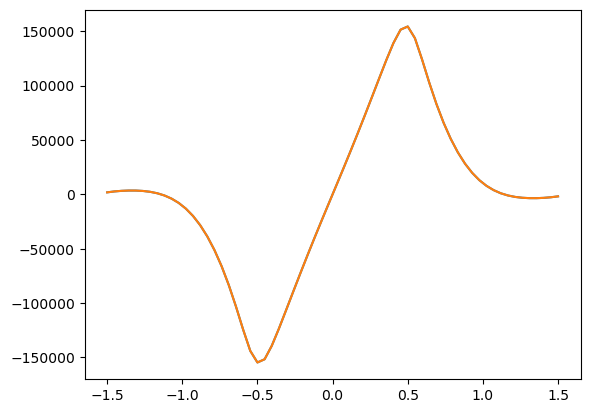

In [5]:
plt.plot(np.linspace(-1.5, 1.5, 64), jt_y[:,34])
plt.plot(np.linspace(-1.5, 1.5, 64), jt_y[:, 34])

# Fitting the curve

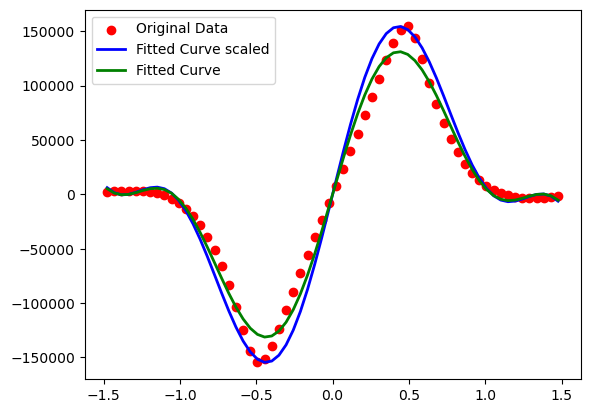

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Define the custom model function (First argument must be x)
def exponential_model(x, a, c, d, e, f, g):
    return g*x**9 + f*x**7 + e*x**5 + a*x**3 + c*x + d

# 2. Generate dummy data with some random noise
x_data = info.z
y_true = jt_y[:, 34]
np.random.seed(42)
y_noise = np.random.normal(size=x_data.size)
y_data = y_true + y_noise

# 3. Fit the function to the data
# p0 provides an optional initial guess for [a, b, c]
initial_guess = [1.0, 1.0, 1.0, 0.0, 1.0, 1.0]
popt, pcov = curve_fit(exponential_model, x_data, y_data, p0=initial_guess)

# 4. Extract optimized parameters
#a_opt, b_opt, c_opt, d_opt, e_opt, f_opt, g_opt = popt
#print(f"Fitted parameters: a={a_opt:.2f}, b={b_opt:.2f}, c={c_opt:.2f}, d={d_opt:.2f}")

# 5. Plot the original data against the fitted curve
plt.scatter(x_data, y_data, label='Original Data', color='red')
y_bar = exponential_model(x_data, *popt)
plt.plot(x_data, (jt_y[idxs] / np.max(y_bar)) * y_bar, label='Fitted Curve scaled', color='blue', linewidth=2)
plt.plot(x_data, y_bar, label='Fitted Curve', color='green', linewidth=2)
plt.legend()
plt.show()

In [7]:
x_data[np.argsort(y_bar)]

array([-0.4453125, -0.3984375, -0.4921875, -0.3515625, -0.5390625,
       -0.3046875, -0.5859375, -0.2578125, -0.6328125, -0.2109375,
       -0.6796875, -0.7265625, -0.1640625, -0.7734375, -0.1171875,
       -0.8203125, -0.8671875, -0.0703125, -0.9140625, -0.9609375,
       -0.0234375,  1.1484375,  1.4765625,  1.1953125, -1.0078125,
        1.1015625,  1.2421875,  1.2890625,  1.4296875,  1.0546875,
       -1.3828125,  1.3359375, -1.3359375,  1.3828125, -1.0546875,
       -1.4296875, -1.2890625, -1.2421875, -1.1015625,  1.0078125,
       -1.1953125, -1.4765625, -1.1484375,  0.0234375,  0.9609375,
        0.9140625,  0.0703125,  0.8671875,  0.8203125,  0.1171875,
        0.7734375,  0.1640625,  0.7265625,  0.6796875,  0.2109375,
        0.6328125,  0.2578125,  0.5859375,  0.3046875,  0.5390625,
        0.3515625,  0.4921875,  0.3984375,  0.4453125])

In [45]:
offset_disk = 4*info.x[idxs[1]] # m
offset_single = 0.0 # m
N = 256
L = 3.0
I = 2.25e4
a = 0.1
b = 1.0
single_turn_r = 0.5
turns = 20

In [46]:
def _build_grid(L, N):
    xs = np.linspace(-L, L, N)
    ys = np.linspace(-L, L, N)
    zs = np.linspace(-L, L, N)
    dx, dy, dz = xs[1] - xs[0], ys[1] - ys[0], zs[1] - zs[0]
    mesh = X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')
    return X, Y, Z, dx, dy, dz, xs, ys, zs, mesh

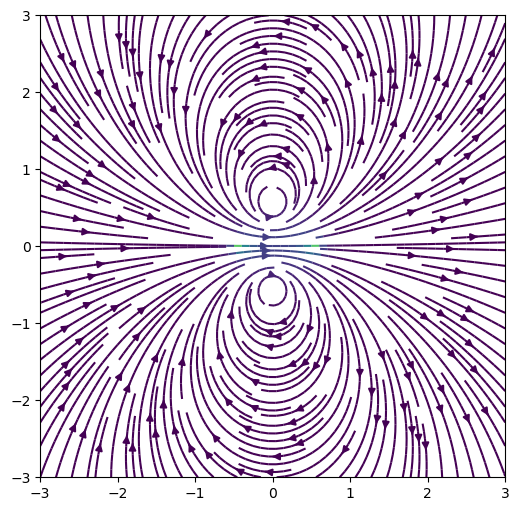

In [33]:
X, Y, Z, dx, dy, dz, xs, ys, zs, mesh = _build_grid(L, N)

A_st_x, A_st_y, A_st_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_single, I, single_turn_r, single_turn_r, 1)
B_curlA_st = curlA(A_st_x, A_st_y, A_st_z, dx, dy, dz)
Bx_st, By_st, Bz_st = B_curlA_st['x'], B_curlA_st['y'], B_curlA_st['z']

Bx_st = Bx_st[:, N//2, :]
By_st = By_st[:, N//2, :]
Bz_st = Bz_st[:, N//2, :]

B_mag = np.sqrt(Bx_st**2 + By_st**2 + Bz_st**2)
fig, ax = plt.subplots(figsize=(6, 6))
plt.streamplot(
    xs, 
    zs, 
    Bx_st.T,
    Bz_st.T,
    color=B_mag,
    density=2.0,
    broken_streamlines=True
    )

plt.show()

In [47]:
X, Y, Z, dx, dy, dz, xs, ys, zs, mesh = _build_grid(L, N)

from src.bext.aext import _Aphi_vec

def _n_turn_Aphi_vec(rho, zeta, I, a, b, n):
    Rs = np.linspace(a, b, n)
    # implies shape = same as rho
    Aphi = np.sum([_Aphi_vec(rho, zeta, R, -exponential_model(k / n, *popt)) for k, R in enumerate(Rs)], axis=0)
    assert Aphi.shape == rho.shape, f"[_n_turn_Aphi_vec] Mismatch in shape {Aphi.shape} != {rho.shape}"
    return Aphi

# A_d_x, A_d_y, A_d_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_disk, -I, a, b, turns, _n_turn_Aphi_vec)
# B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
# Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']

Bs = {
    'x': [],
    'y': [],
    'z': []
}
turns = [2, 4, 8, 16, 32]
for turn in turns:
    print(f'On turn {turn} of max {turns[-1]}', end='\r')
    A_d_x, A_d_y, A_d_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_disk, -I, a, b, turn, _n_turn_Aphi_vec)
    B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
    Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']
    Bs['x'].append(Bx_d)
    Bs['y'].append(By_d)
    Bs['z'].append(Bz_d)

# Bx_d = Bx_d[:, N//2, :]
# By_d = By_d[:, N//2, :]
# Bz_d = Bz_d[:, N//2, :]

# B_mag_d = np.sqrt(Bx_d**2 + By_d**2 + Bz_d**2)
# fig, ax = plt.subplots(figsize=(6, 6))
# plt.streamplot(
#     xs, 
#     zs, 
#     Bx_d.T,
#     Bz_d.T,
#     color=B_mag_d,
#     density=2.0,
#     broken_streamlines=True
#     )

# plt.show()

KeyboardInterrupt: 

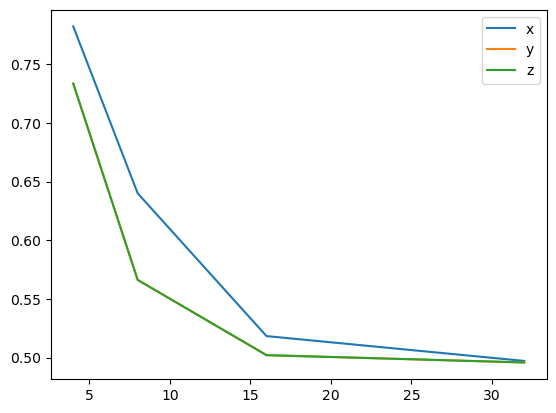

In [30]:
err_min = {
    'x': [],
    'y': [],
    'z': []
}
for axis in ['x', 'y', 'z']:
    print(f'On axis: {axis}', end='\r')
    for k in range(1, len(Bs[axis])):
        num = np.linalg.norm(Bs[axis][k] - Bs[axis][k-1])
        den = np.linalg.norm(Bs[axis][k])
        err_min[axis].append(num / den)

    plt.plot(turns[1:], err_min[axis], label=f'{axis}')

plt.legend()

In [48]:
turn=32
A_d_x, A_d_y, A_d_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_disk, -I, a, b, turn, _n_turn_Aphi_vec)
B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']
Bs['x'].append(Bx_d)
Bs['y'].append(By_d)
Bs['z'].append(Bz_d)

In [50]:
Bx_d = Bx_d[:, N//2, :]
By_d = By_d[:, N//2, :]
Bz_d = Bz_d[:, N//2, :]

B_mag_d = np.sqrt(Bx_d**2 + By_d**2 + Bz_d**2)
fig, ax = plt.subplots(figsize=(6, 6))
plt.streamplot(
    xs, 
    zs, 
    Bx_d.T,
    Bz_d.T,
    color=B_mag_d,
    density=2.0,
    broken_streamlines=True
    )

plt.show()

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

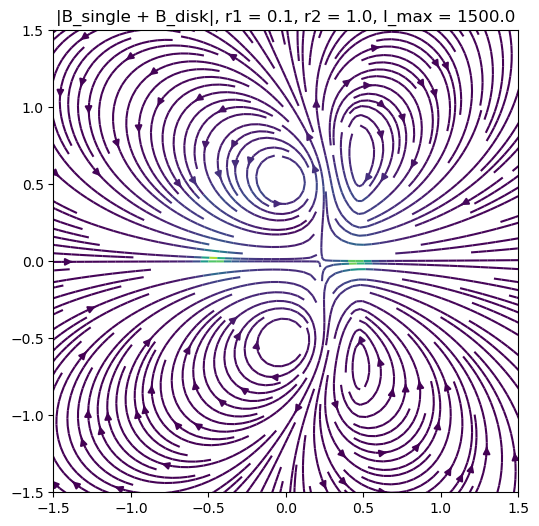

In [52]:
factor = 0.01
B_tot_x = Bx_st + factor * Bx_d 
B_tot_y = By_st + factor * By_d 
B_tot_z = Bz_st + factor * Bz_d

B_tot_mag = np.sqrt(B_tot_x**2 + B_tot_y**2 + B_tot_z**2)

fig, ax = plt.subplots(figsize=(6, 6))
plt.streamplot(
    xs, 
    zs, 
    B_tot_x.T,
    B_tot_z.T,
    color=B_tot_mag,
    density=4.0,
    broken_streamlines=True
    )

plt.title(f'|B_single + B_disk|, r1 = {a}, r2 = {b}, I_max = {factor * 150000}')

plt.xlim((-1.5, 1.5))
plt.ylim((-1.5, 1.5))

plt.show()

# Increase current of flat disk over time

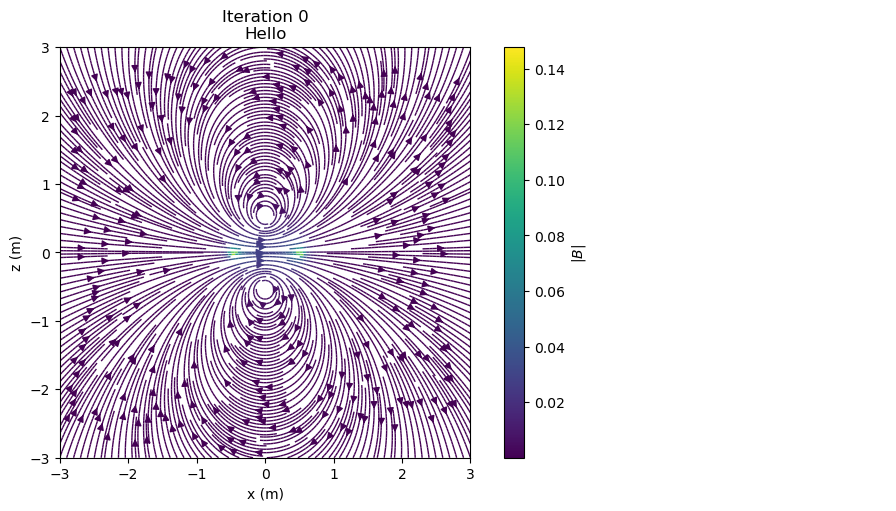

In [53]:
import matplotlib.animation as animation
import matplotlib.colors as mcolors

X, Y, Z, dx, dy, dz, xs, ys, zs, mesh = _build_grid(L, N)

# A_st_x, A_st_y, A_st_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_single, I, single_turn_r, single_turn_r, 1)
# B_curlA_st = curlA(A_st_x, A_st_y, A_st_z, dx, dy, dz)
# Bx_st, By_st, Bz_st = B_curlA_st['x'], B_curlA_st['y'], B_curlA_st['z']

streams = []
for i in range(0, 101):

    print(f'Iteration: {i} / 100', end='\r')

    # A_d_x, A_d_y, A_d_z = aext._A_single_n_turn_coil_with_linear_dropoff_current(X, Y, Z, 'x', offset_disk, -i, a, b, turns)
    # B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
    # Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']
    # Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']
    cur_Bxd = Bx_d * (i / 10000)
    cur_Byd = By_d * (i / 10000)
    cur_Bzd = Bz_d * (i / 10000)

    B_tot_x = Bx_st + cur_Bxd
    B_tot_y = By_st + cur_Byd 
    B_tot_z = Bz_st + cur_Bzd

    B_tot_mag = np.sqrt(B_tot_x**2 + B_tot_y**2 + B_tot_z**2)

    streams.append([B_tot_x, B_tot_z, B_tot_mag, i])

# Animate
B_max = max(b[2].max() for b in streams)

fig, (ax, ax_text) = plt.subplots(1, 2, figsize=(10, 5), layout='constrained', width_ratios=[2, 1])
ax_text.axis('off')
ax.set_aspect('equal')
vmax = np.max([b[2] for b in streams])
vmin = np.min([b[2] for b in streams])
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)  # Explicitly enforces 0 as white across all frames
im = ax.streamplot(
    x=xs,
    y=zs,
    u=streams[0][0].T,
    v=streams[0][1].T,
    color=streams[0][2], norm=norm,
    cmap="viridis", density=4.0, linewidth=1,
    broken_streamlines=True,
)

cbar = fig.colorbar(im.lines, ax=ax, label=r'$|B|$')

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
title = ax.set_title('Iteration 0\nHello')

plt.show()

In [55]:
def update(k):
    print(f'iteration: {k}', end='\r')
    ax.cla()
    im = ax.streamplot(
        x=xs,
        y=zs,
        u=streams[k][0].T,
        v=streams[k][1].T,
        color=streams[k][2],
        cmap="viridis", density=4.0, linewidth=1
    )
    #t_us = series_f.t[k] * 1e6
    ax.set_title(f'|B_single + B_disk|, r1 = {a}, r2 = {b}\nI = {I / 4 * (k / 100)}, dropoff rate = 1 / turn_i')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    ax.set_xlim((-1.5, 1.5))
    ax.set_ylim((-1.5, 1.5))
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(streams), interval=100)
ani.save(f'single_vs_disk.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.close()
print(f"Saved: single_vs_disk.mp4")

Saved: single_vs_disk.mp4


# Flux through ring

$\int \int B_x(x=0, y, z) dydz \approx \sum_i \sum_j B_x(x\approx0, y_i, z_j) \Delta y \Delta z $ Webers

In [56]:

x_index = np.argmin(np.abs(xs))

actual_x_position = xs[x_index]
error = abs(actual_x_position - 0.0)
print(f"Target X: {0.0}m | Grid X: {actual_x_position}m | Alignment Error: {error}m")

A_st_x, A_st_y, A_st_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_single, I, single_turn_r, single_turn_r, 1)
B_curlA_st = curlA(A_st_x, A_st_y, A_st_z, dx, dy, dz)
Bx_st, By_st, Bz_st = B_curlA_st['x'], B_curlA_st['y'], B_curlA_st['z']

Bx_st_area = Bx_st[x_index, :, :]
# By_st = By_st[:, :, :]
# Bz_st = Bz_st[:, :, :]

A_d_x, A_d_y, A_d_z = aext._A_single_n_turn_coil_with_linear_dropoff_current(X, Y, Z, 'x', offset_disk, -I/4, a, b, turns)
B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']

Bx_d_area = Bx_d[x_index, :, :]
# By_d = By_d[:, N//2, :]
# Bz_d = Bz_d[:, N//2, :]

B_tot_x_area = Bx_st_area + Bx_d_area
# B_tot_y = By_st + By_d 
# B_tot_z = Bz_st + Bz_d

fluxes = []
for r in np.linspace(0.1, single_turn_r, 10):
    area_coil = np.sqrt(Y**2 + Z**2) < r
    # Extract only those who are within the coil area
    B_tot_x_circle = B_tot_x[area_coil[x_index, :, :]]

    flux = np.sum(B_tot_x_circle) * dy * dz

    fluxes.append(flux)

plt.plot(np.linspace(0.1, single_turn_r, 10), fluxes)

Target X: 0.0m | Grid X: -0.0117647058823529m | Alignment Error: 0.0117647058823529m


TypeError: 'list' object cannot be interpreted as an integer

In [16]:
A_st_x, A_st_y, A_st_z = _A_single_n_turn_coil(X, Y, Z, 'x', offset_single, I, single_turn_r, single_turn_r, 1)
B_curlA_st = curlA(A_st_x, A_st_y, A_st_z, dx, dy, dz)
Bx_st, By_st, Bz_st = B_curlA_st['x'], B_curlA_st['y'], B_curlA_st['z']

Bx_st_area = Bx_st[x_index, :, :]

A_d_x, A_d_y, A_d_z = aext._A_single_n_turn_coil_with_linear_dropoff_current(X, Y, Z, 'x', offset_disk, -I/4, a, b, turns)
B_curlA_d = curlA(A_d_x, A_d_y, A_d_z, dx, dy, dz)
Bx_d, By_d, Bz_d = B_curlA_d['x'], B_curlA_d['y'], B_curlA_d['z']

x_index = np.argmin(np.abs(xs))

Bx_d_area = Bx_d[x_index, :, :]

area_mask = np.sqrt(Y**2 + Z**2) < single_turn_r

In [17]:
fluxes = {
    'f': [],
    'I': [],
}
for i in range(0, 101):
    print("Iteration: {i} / 100", end='\r')
    cur_Bxd = Bx_d_area * (i / 100)
    B_tot_x = Bx_st_area + cur_Bxd
    B_tot_x_circle = B_tot_x[area_mask[x_index, :, :]]
    flux = np.sum(B_tot_x_circle) * dy * dz
    fluxes['f'].append(flux)
    fluxes['I'].append((I/4)*(i/100))

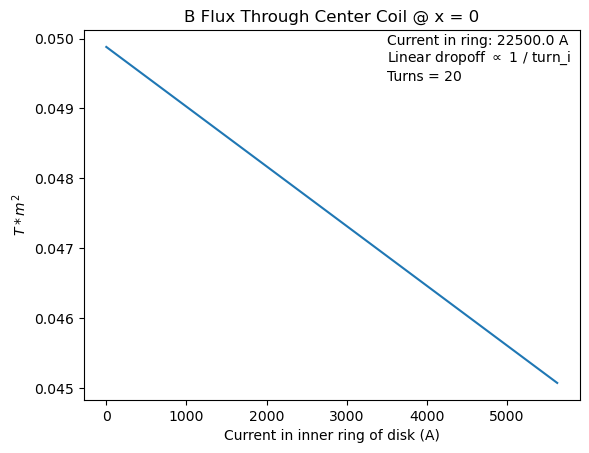

In [18]:
plt.plot(fluxes['I'], fluxes['f'])
plt.ylabel(r'$T*m^2$')
plt.xlabel(r'Current in inner ring of disk (A)')
plt.title('B Flux Through Center Coil @ x = 0')
plt.text(3500, 0.0494, f"Current in ring: {I} A\nLinear dropoff $\propto$ 1 / turn_i\nTurns = {turns}")
plt.savefig('poorman_flux.png')